In [1]:
import sys
sys.path.append("../src")

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def newton_fractal(func, dfunc, xlim=(-1.5, 1.5), ylim=(-1.5, 1.5),
                   resolution=500, max_iter=50, tol=1e-6):
    """
    roots : ndarray of complex
        Array of discovered root values.
    root_index : ndarray of shape (resolution, resolution)
        Integer index mapping each pixel to a root (0..len(roots)-1).
    iters : ndarray of shape (resolution, resolution)
        Number of iterations taken to converge (max_iter if not converged).
    img : ndarray
        Float image array (root index + normalized iteration) suitable for imshow.
    """
    re = np.linspace(xlim[0], xlim[1], resolution)
    im = np.linspace(ylim[0], ylim[1], resolution)
    Re, Im = np.meshgrid(re, im[::-1])  # flip im so image y axis is conventional
    z = Re + 1j * Im
    z = z.astype(np.complex128)
    
    # iteration trackers
    iters = np.full(z.shape, max_iter, dtype=int)
    converged = np.zeros(z.shape, dtype=bool)
    
    # Newton iterations (vectorized)
    for k in range(max_iter):
        # avoid division by zero: add tiny epsilon where derivative is zero
        derivative = dfunc(z) + 1e-12 # avoid div by 0
        # Newton step
        z_next = z - func(z) / derivative
        # check convergence using function value
        just_converged = (~converged) & (np.abs(func(z_next)) < tol)
        iters[just_converged] = k
        converged = converged | just_converged
        z = z_next
    
    # After iterations, group final z into distinct roots
    flat_z = z.ravel()
    flat_converged = converged.ravel()
    root_list = []
    root_index_flat = np.full(flat_z.shape, -1, dtype=int)
    root_tol = 1e-3  # tolerance for considering two z values the same root
    for i, val in enumerate(flat_z):
        assigned = False
        if not flat_converged[i]:
            root_index_flat[i] = -1
        else:
            for r_idx, r in enumerate(root_list):
                if np.abs(val - r) < root_tol:
                    root_index_flat[i] = r_idx
                    assigned = True
                    break
            if not assigned:
                root_list.append(val)
                root_index_flat[i] = len(root_list) - 1
    roots = np.array(root_list)
    root_index = root_index_flat.reshape(z.shape)
    return roots, root_index, iters

In [4]:
def e_surf(k_hats, qs, ms, Q, k):
    k = np.expand_dims(k,axis = -1)
    return sum(np.sqrt(np.sum((k_hat * k+q)**2, axis = -1) + m**2) for q, m, k_hat in zip(qs, ms, k_hats))+Q


def d_e_surf(k_hats, qs, ms, k):
    k = np.expand_dims(k,axis = -1)
    return sum(np.sum(k_hat*(k_hat * k + q), axis = -1)/np.sqrt(np.sum((k_hat * k + q)**2, axis = -1) + m**2) for q, m, k_hat in zip(qs, ms, k_hats))

In [5]:
from matplotlib.colors import hsv_to_rgb

def make_image(k_hat, qs, ms, Q, xlim, ylim, res, fig = None):
    if fig is None:
        fig = plt.figure()
    # Generate fractal
    roots, root_index, iters = newton_fractal(
    lambda k: e_surf(k_hat, qs, ms, Q, k),
    lambda k: d_e_surf(k_hat, qs, ms, k),
    xlim=xlim,
    ylim=ylim,
    resolution=res,
    max_iter=50,
    tol=1e-12,
    )

    x = np.linspace(*xlim, res)
    y = np.linspace(*ylim, res)
    X, Y = np.meshgrid(x, y)
    xs = X + 1j*Y
    e_surface = 1/e_surf(k_hat, qs, ms, Q, xs)
    # magnitude → brightness
    mag = np.log(np.abs(e_surface)+0.01)
    mag = mag / mag.max()    # normalize to [0,1]
    mag = mag - mag.min()
    # phase → hue
    phase = np.angle(e_surface)
    phase = (phase + np.pi) / (2*np.pi)   # map [-pi,pi] to [0,1]

    hsv = np.zeros(e_surface.shape + (3,))
    hsv[..., 0] = phase
    hsv[..., 1] = 1
    hsv[..., 2] = mag
    img = hsv_to_rgb(hsv)

    ax = fig.subplots(1,2)
    ax[0].imshow(
        root_index, extent=xlim+ylim, origin="lower"
    )
    ax[0].set_xlabel("Re")
    ax[0].set_ylabel("Im")
    ax[0].scatter(roots.real, roots.imag, c='white')
    ax[0].tight_layout()

    ax[1].imshow(
        img, extent=xlim+ylim, origin="lower"
    )
    ax[1].set_xlabel("Re")
    ax[1].set_ylabel("Im")
    fig.tight_layout()

In [6]:
def make_image_data(k_hat, qs, ms, Q, xlim, ylim, res, max_iter):
    roots, root_index, iters = newton_fractal(
        lambda k: e_surf(k_hat, qs, ms, Q, k),
        lambda k: d_e_surf(k_hat, qs, ms, k),
        xlim=xlim,
        ylim=ylim,
        resolution=res,
        max_iter=max_iter,
        tol=1e-12,
    )

    x = np.linspace(*xlim, res)
    y = np.linspace(*ylim, res)
    X, Y = np.meshgrid(x, y)
    xs = X + 1j*Y
    e_surface = 1 / e_surf(k_hat, qs, ms, Q, xs)

    mag = np.log(np.abs(e_surface) + 0.01)
    mag = (mag - mag.min()) / (mag.max() - mag.min())

    phase = np.angle(e_surface)
    phase = (phase + np.pi) / (2 * np.pi)

    hsv = np.zeros(e_surface.shape + (3,))
    hsv[..., 0] = phase
    hsv[..., 1] = 1
    hsv[..., 2] = mag

    img = hsv_to_rgb(hsv)
    return root_index, roots, img


In [7]:
RES = 300
N = 10
xlim = (-N*1.5,N*2.5)
ylim = (-N*2,N*2)
k_hat = [np.array([1/np.sqrt(N),0,0])]*N
qs = [np.array([i-N//2, 1, 0]) for i in range(N)]
ms = [0.5*i-0.1j for i in range(1,N*1)]

Qs = np.linspace(-40, -20, 21)


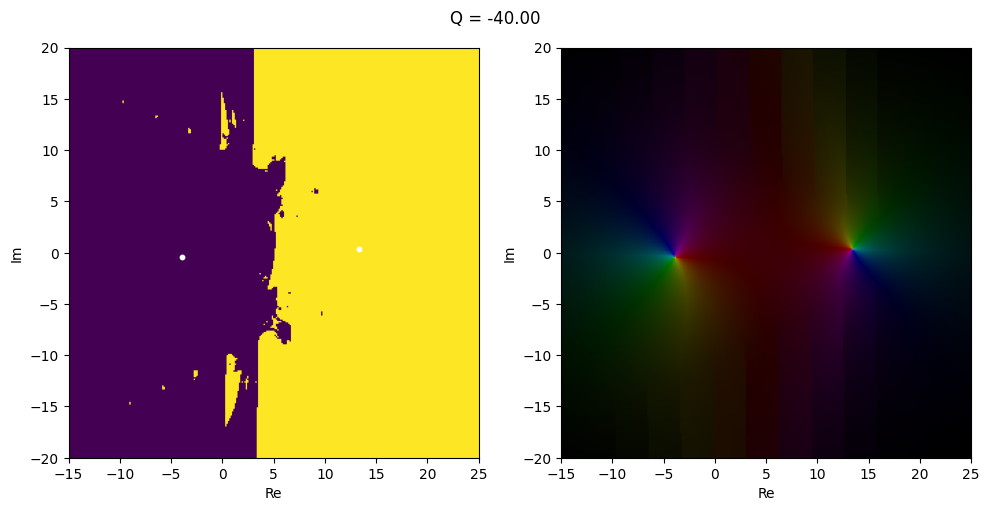

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5))

root_index0, roots0, img0 = make_image_data(
    k_hat, qs, ms, Qs[0], xlim, ylim, RES, 20
)

im_roots = axs[0].imshow(
    root_index0, extent=xlim + ylim, origin="lower"
)
scat = axs[0].scatter(
    roots0.real, roots0.imag, c="white", s=10
)

im_img = axs[1].imshow(
    img0, extent=xlim + ylim, origin="lower"
)

for ax in axs:
    ax.set_xlabel("Re")
    ax.set_ylabel("Im")

title = fig.suptitle(f"Q = {Qs[0]:.2f}")
fig.tight_layout()


In [9]:
def update(i):
    root_index, roots, img = make_image_data(
        k_hat, qs, ms, Qs[i], xlim, ylim, RES, 20
    )

    im_roots.set_data(root_index)
    scat.set_offsets(np.c_[roots.real, roots.imag])
    im_img.set_data(img)

    title.set_text(f"Q = {Qs[i]:.2f}")
    fig.savefig(f"../images/newton/{i:03d}.png", dpi=300)
    return im_roots, scat, im_img, title


In [10]:
from matplotlib.animation import FuncAnimation

#takes ~13 min.


ani = FuncAnimation(
    fig,
    update,
    frames=len(Qs),
    interval=200,
)

ani.save("../images/newton/animation.gif", dpi=300)
